In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv("C:/Users/Veena S Lal/Downloads/European Restaurant Reviews.csv")

In [3]:
df.head()

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
0,France,The Frog at Bercy Village,Negative,Rude manager,May 2024 •,The manager became agressive when I said the c...
1,France,The Frog at Bercy Village,Negative,A big disappointment,Feb 2024 •,"I ordered a beef fillet ask to be done medium,..."
2,France,The Frog at Bercy Village,Negative,Pretty Place with Bland Food,Nov 2023 •,"This is an attractive venue with welcoming, al..."
3,France,The Frog at Bercy Village,Negative,Great service and wine but inedible food,Mar 2023 •,Sadly I used the high TripAdvisor rating too ...
4,France,The Frog at Bercy Village,Negative,Avoid- Worst meal in Rome - possibly ever,Nov 2022 •,From the start this meal was bad- especially g...


In [4]:
df.tail()

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
1497,Cuba,Old Square (Plaza Vieja),Negative,The Tourism Trap,Oct 2016 •,Despite the other reviews saying that this is ...
1498,Cuba,Old Square (Plaza Vieja),Negative,the beer factory,Oct 2016 •,beer is good. food is awfull The only decent...
1499,Cuba,Old Square (Plaza Vieja),Negative,brewery,Oct 2016 •,"for terrible service of a truly comedic level,..."
1500,Cuba,Old Square (Plaza Vieja),Negative,It's nothing exciting over there,Oct 2016 •,We visited the Havana's Club Museum which is l...
1501,Cuba,Old Square (Plaza Vieja),Negative,Tourist Trap,Oct 2016 •,Food and service was awful. Very pretty stop. ...


In [5]:
df.describe()

,Country,Restaurant Name,Sentiment,Review Title,Review Date,Review
count,1502,1502,1502,1502,1502,1502
unique,7,7,2,1343,143,1426
top,France,The Frog at Bercy Village,Positive,Excellent,May 2014 •,I'm afraid we were very let down by this resta...
freq,512,512,1237,9,108,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Country          1502 non-null   object
 1   Restaurant Name  1502 non-null   object
 2   Sentiment        1502 non-null   object
 3   Review Title     1502 non-null   object
 4   Review Date      1502 non-null   object
 5   Review           1502 non-null   object
dtypes: object(6)
memory usage: 70.5+ KB


In [7]:
df['Review_Title_Length']=df['Review Title'].apply(len)

In [8]:
df.Review_Title_Length.describe()

count    1502.000000
mean       24.561252
std        15.164254
min         1.000000
25%        14.000000
50%        21.000000
75%        32.000000
max       120.000000
Name: Review_Title_Length, dtype: float64

In [9]:
df_120=df[df['Review_Title_Length']==120]['Review Title']
for message in df_120:
    print(message)

Ojahwee provided exceptional service during my visit for a pint and some chana masala. The popadoms were crispy and deli


In [10]:
# Patch numpy.asarray to ignore 'copy' argument
_original_asarray = np.asarray

def _patched_asarray(a, *args, **kwargs):
    kwargs.pop("copy", None)
    return _original_asarray(a, *args, **kwargs)

np.asarray = _patched_asarray

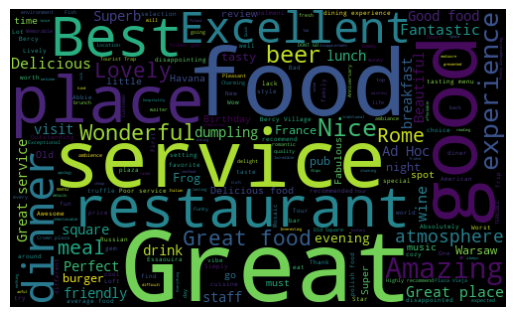

In [11]:
all_messages=' '.join(df['Review Title'].dropna())
wc=WordCloud(width=500,height=300,random_state=20,max_font_size=100).generate(all_messages)
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.show()

In [12]:
df['Review_Length']=df['Review'].apply(len)

In [13]:
df.Review_Length.describe()

count    1502.000000
mean      366.438083
std       399.792336
min        10.000000
25%       147.000000
50%       236.000000
75%       416.750000
max      3679.000000
Name: Review_Length, dtype: float64

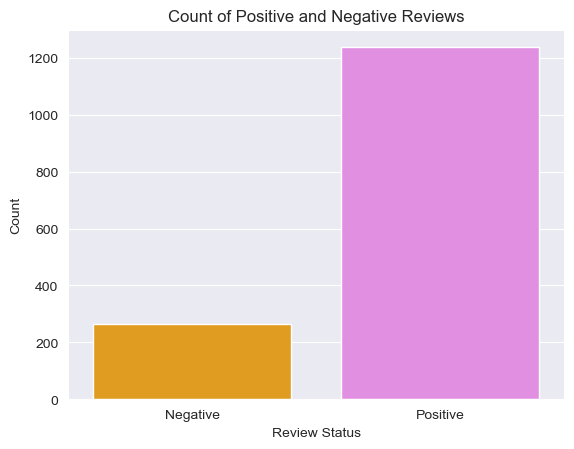

In [77]:
sns.set_style('darkgrid')
palette = {"Positive": "violet","Negative": "orange"}
sns.countplot(x='Sentiment',hue='Sentiment',data=df,palette=palette,legend=False)
plt.title('Count of Positive and Negative Reviews')
plt.xlabel('Review Status')
plt.ylabel('Count')
plt.show()

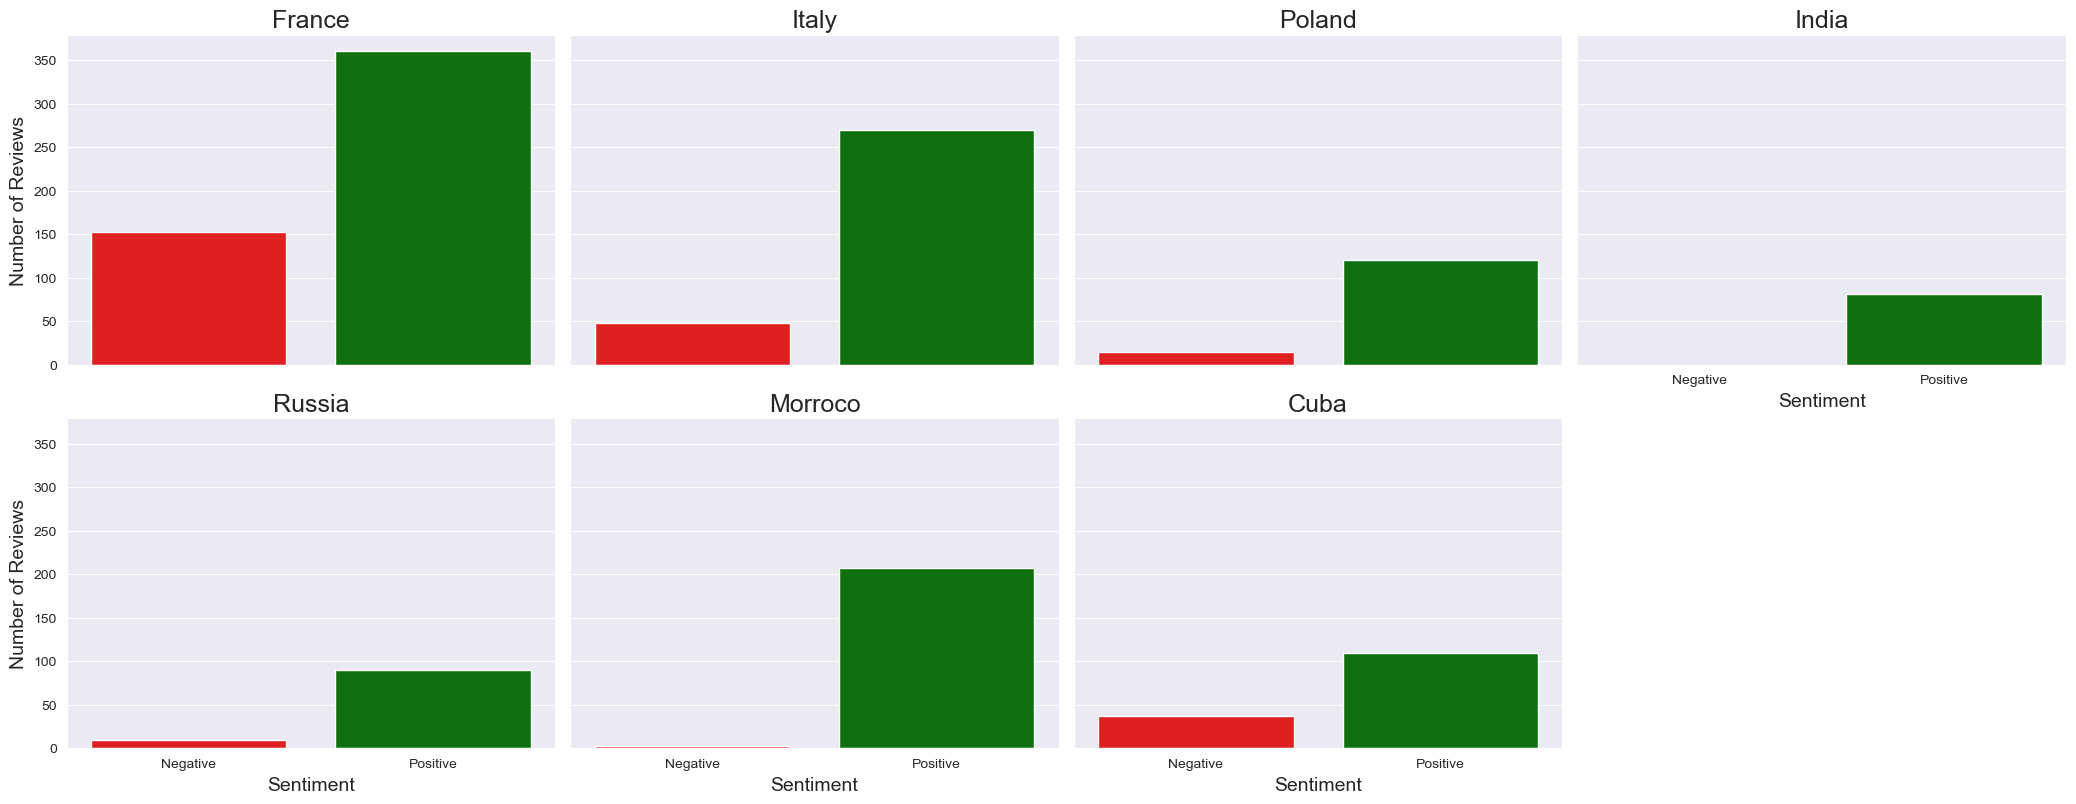

In [15]:
g = sns.catplot(data=df,x="Sentiment",hue="Sentiment",col="Country",kind="count",col_wrap=4,
                palette={"Positive":"green","Negative":"red"},
                legend=False,height=4,aspect=1.3)

g.set_axis_labels("Sentiment", "Number of Reviews", fontsize=14)
g.set_titles("{col_name}", size=18)

<Axes: xlabel='Sentiment', ylabel='Country'>

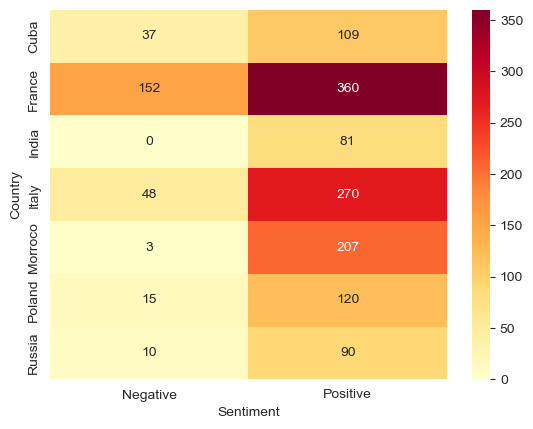

In [16]:
pivot = pd.crosstab(df["Country"], df["Sentiment"])

sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd")

<Axes: xlabel='Review Date', ylabel='count'>

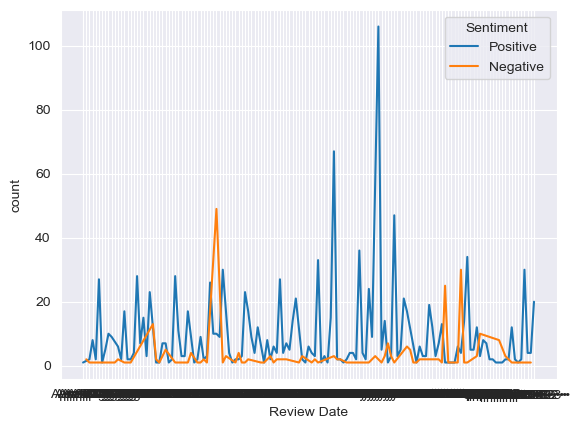

In [17]:
sentiment_time = (df.groupby(["Review Date", "Sentiment"]).size().reset_index(name="count"))

sns.lineplot(data=sentiment_time,x="Review Date", y="count",hue="Sentiment")

Text(0.5, 1.0, 'Text Length vs Sentiment')

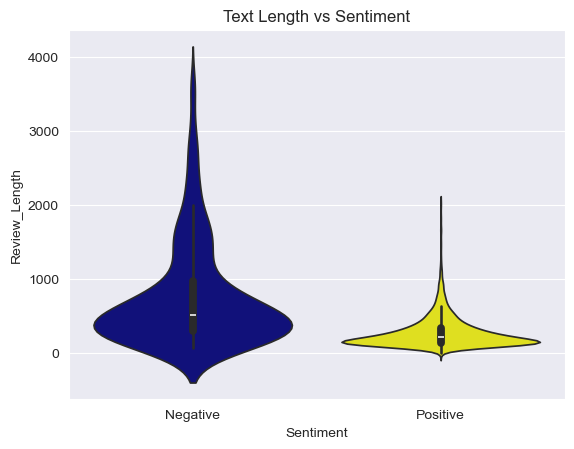

In [75]:
palette = {"Positive": "yellow","Negative": "darkblue"}
sns.violinplot(data=df,x="Sentiment",y="Review_Length",hue='Sentiment',palette=palette,legend=False)
plt.title('Text Length vs Sentiment')

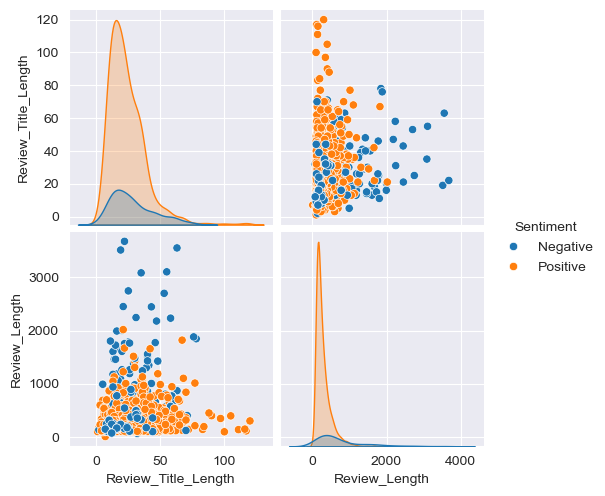

In [19]:
sns.pairplot(df, hue="Sentiment")

In [20]:
pipeline=Pipeline([
    ('bow',CountVectorizer()),
    ('tfidf',TfidfTransformer()),
    ('classifier',MultinomialNB())
])

In [21]:
x=df['Review']
y=df['Sentiment']
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [22]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('bow', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [23]:
y_pred_nb=pipeline.predict(x_test)
print(y_pred_nb)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Posit

In [24]:
print(confusion_matrix(y_test,y_pred_nb))

[[  2  70]
 [  0 304]]


In [25]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

    Negative       1.00      0.03      0.05        72
    Positive       0.81      1.00      0.90       304

    accuracy                           0.81       376
   macro avg       0.91      0.51      0.48       376
weighted avg       0.85      0.81      0.74       376



In [26]:
accuracy_nb=accuracy_score(y_test,y_pred_nb)
print("Accuracy:",accuracy_nb)

Accuracy: 0.8138297872340425


In [27]:
precision_nb=metrics.precision_score(y_test,y_pred_nb,pos_label='Positive')
precision_nb

0.8128342245989305

In [28]:
recall_nb=metrics.recall_score(y_test,y_pred_nb,pos_label='Positive')
recall_nb

1.0

In [29]:
f1_score_nb=metrics.f1_score(y_test,y_pred_nb,pos_label='Positive')
f1_score_nb

0.8967551622418879

In [30]:
pipeline_2= Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline_2.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

In [31]:
y_pred_log=pipeline_2.predict(x_test)
print(y_pred_log)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Negative' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Posit

In [32]:
print(confusion_matrix(y_test,y_pred_log))

[[ 31  41]
 [  0 304]]


In [33]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

    Negative       1.00      0.43      0.60        72
    Positive       0.88      1.00      0.94       304

    accuracy                           0.89       376
   macro avg       0.94      0.72      0.77       376
weighted avg       0.90      0.89      0.87       376



In [34]:
accuracy_log=accuracy_score(y_test,y_pred_log)
print("Accuracy:",accuracy_log)

Accuracy: 0.8909574468085106


In [35]:
precision_log=metrics.precision_score(y_test,y_pred_log,pos_label='Positive')
precision_log

0.881159420289855

In [36]:
recall_log=metrics.recall_score(y_test,y_pred_log,pos_label='Positive')
recall_log

1.0

In [37]:
f1_score_log=metrics.f1_score(y_test,y_pred_log,pos_label='Positive')
f1_score_log

0.9368258859784283

In [38]:
# Pipeline
pipeline_3 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', DecisionTreeClassifier())
])

# Train
pipeline_3.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', DecisionTreeClassifier())])

In [39]:
y_pred_dt=pipeline_3.predict(x_test)
print(y_pred_dt)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Negative' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Negative' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Posit

In [40]:
print(confusion_matrix(y_test,y_pred_dt))

[[ 50  22]
 [ 22 282]]


In [41]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

    Negative       0.69      0.69      0.69        72
    Positive       0.93      0.93      0.93       304

    accuracy                           0.88       376
   macro avg       0.81      0.81      0.81       376
weighted avg       0.88      0.88      0.88       376



In [42]:
accuracy_dt=accuracy_score(y_test,y_pred_dt)
print("Accuracy:",accuracy_dt)

Accuracy: 0.8829787234042553


In [43]:
precision_dt=metrics.precision_score(y_test,y_pred_dt,pos_label='Positive')
precision_dt

0.9276315789473685

In [44]:
recall_dt=metrics.recall_score(y_test,y_pred_dt,pos_label='Positive')
recall_dt

0.9276315789473685

In [45]:
f1_score_dt=metrics.f1_score(y_test,y_pred_dt,pos_label='Positive')
f1_score_dt

0.9276315789473685

In [46]:
# Pipeline
pipeline_4 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LinearSVC())
])

# Train
pipeline_4.fit(x_train, y_train)

C:\New folder\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LinearSVC())])

In [47]:
y_pred_svm=pipeline_4.predict(x_test)
print(y_pred_svm)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Negative' 'Positive' 'Positive' 'Positive'
 'Negative' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Posit

In [48]:
print(confusion_matrix(y_test,y_pred_svm))

[[ 56  16]
 [  1 303]]


In [49]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

    Negative       0.98      0.78      0.87        72
    Positive       0.95      1.00      0.97       304

    accuracy                           0.95       376
   macro avg       0.97      0.89      0.92       376
weighted avg       0.96      0.95      0.95       376



In [50]:
accuracy_svm=accuracy_score(y_test,y_pred_svm)
print("Accuracy:",accuracy_svm)

Accuracy: 0.9547872340425532


In [51]:
precision_svm=metrics.precision_score(y_test,y_pred_dt,pos_label='Positive')
precision_svm

0.9276315789473685

In [52]:
recall_svm=metrics.recall_score(y_test,y_pred_svm,pos_label='Positive')
recall_svm

0.9967105263157895

In [53]:
f1_score_svm=metrics.f1_score(y_test,y_pred_svm,pos_label='Positive')
f1_score_svm

0.9727126805778491

In [54]:
# Pipeline
pipeline_5 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', RandomForestClassifier())
])

# Train
pipeline_5.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', RandomForestClassifier())])

In [55]:
y_pred_rfc=pipeline_5.predict(x_test)
print(y_pred_rfc)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Negative' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Posit

In [56]:
print(confusion_matrix(y_test,y_pred_rfc))

[[ 41  31]
 [  0 304]]


In [57]:
print(classification_report(y_test,y_pred_rfc))

              precision    recall  f1-score   support

    Negative       1.00      0.57      0.73        72
    Positive       0.91      1.00      0.95       304

    accuracy                           0.92       376
   macro avg       0.95      0.78      0.84       376
weighted avg       0.93      0.92      0.91       376



In [58]:
accuracy_rfc=accuracy_score(y_test,y_pred_rfc)
print("Accuracy:",accuracy_rfc)

Accuracy: 0.9175531914893617


In [59]:
precision_rfc=metrics.precision_score(y_test,y_pred_rfc,pos_label='Positive')
precision_rfc

0.9074626865671642

In [60]:
recall_rfc=metrics.recall_score(y_test,y_pred_svm,pos_label='Positive')
recall_rfc

0.9967105263157895

In [61]:
f1_score_rfc=metrics.f1_score(y_test,y_pred_rfc,pos_label='Positive')
f1_score_rfc

0.9514866979655712

In [62]:
pipeline_6 = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', AdaBoostClassifier())
])
pipeline_6.fit(x_train, y_train)

C:\New folder\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', AdaBoostClassifier())])

In [63]:
y_pred_ada=pipeline_6.predict(x_test)
print(y_pred_ada)

['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Negative' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Negative' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Negative' 'Negative' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive' 'Negative' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Negative' 'Positive' 'Posit

In [64]:
print(confusion_matrix(y_test,y_pred_ada))

[[ 50  22]
 [  8 296]]


In [65]:
print(classification_report(y_test,y_pred_ada))

              precision    recall  f1-score   support

    Negative       0.86      0.69      0.77        72
    Positive       0.93      0.97      0.95       304

    accuracy                           0.92       376
   macro avg       0.90      0.83      0.86       376
weighted avg       0.92      0.92      0.92       376



In [66]:
accuracy_ada=accuracy_score(y_test,y_pred_ada)
print("Accuracy:",accuracy_ada)

Accuracy: 0.9202127659574468


In [67]:
precision_ada=metrics.precision_score(y_test,y_pred_ada,pos_label='Positive')
precision_ada

0.9308176100628931

In [68]:
recall_ada=metrics.recall_score(y_test,y_pred_svm,pos_label='Positive')
recall_ada

0.9967105263157895

In [69]:
f1_score_ada=metrics.f1_score(y_test,y_pred_rfc,pos_label='Positive')
f1_score_ada

0.9514866979655712

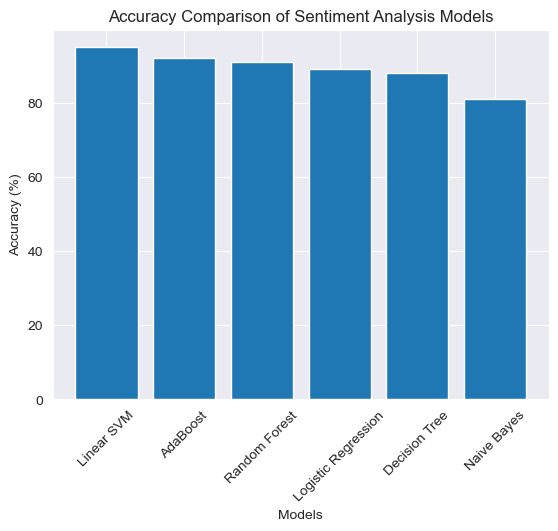

In [74]:
models = [
    'Linear SVM',
    'AdaBoost',
    'Random Forest',
    'Logistic Regression',
    'Decision Tree',
    'Naive Bayes'
]
accuracies = [95, 92, 91, 89, 88, 81]
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison of Sentiment Analysis Models')
plt.xticks(rotation=45)
plt.show()